# 05 - Retention scenarios (model-based, not causal)
Code: `src/churn/scenarios.py`.

> **At a glance**
> * Population: the 1,657 members active on 2024-06-30, scored for Jul-Sep 2024. The riskiest 20% (331 members) hold
>   131 of the 140 expected churners.
> * Each action changes the member's recent behaviour by **half the observed gap between retained and churning
>   members** (sensitivity: 25% and 100%), never beyond the retained-member average.
> * Central case: engagement outreach -10.2 pp predicted risk (about 34 fewer expected churners in the target group);
>   targeted coupon -2.7 pp; proactive support -3.4 pp.
> * These numbers rank what to **test**; they are not what the actions will achieve.

In [1]:
%matplotlib inline
from churn.notebook import *   # pandas as pd, numpy as np, display, Markdown, fig(), tab(), run_step(), paths P

## 1. Baseline: where the risk sits

In [2]:
tab("retention_target_group").round(3)

,segment,members,mean_predicted_risk,expected_churners
0,all active members,1657,0.085,140.215
1,targeted top 20%,331,0.396,131.219
2,rest of active members,1326,0.007,8.996


## 2. How big is each assumed change? Grounded in the data

In [3]:
tab("scenario_behaviour_gaps").round(3)

,feature,behaviour,retained,churned,gap_retained_minus_churned
0,app_avg_3m,app sessions,2.201,0.626,1.576
1,email_avg_3m,emails opened,1.072,0.425,0.646
2,coupons_avg_3m,coupons redeemed,0.595,0.235,0.360
3,tickets_avg_3m,support tickets,0.126,0.350,-0.224


Retained active members open about 0.65 more emails, have about 1.6 more app sessions and redeem about 0.36 more
coupons a month than members who churn, and raise fewer tickets (0.13 vs 0.35 a month). The central scenario assumes an
action closes **half** of that gap for the members it applies to. This replaces arbitrary magnitudes ("+1 coupon")
with a stated, data-based assumption that can be changed.

## 3. Results

,scenario,who,change_per_member,members_eligible_for_action,mean_risk_before_eligible,mean_risk_after_eligible,change_pp_eligible,expected_churners_avoided_model_based
0,A. proactive support outreach,members with at least one support ticket in the last 3 months,support tickets -0.11/month,157,0.504,0.471,-3.357,5.270
1,B. targeted coupon,members redeeming fewer coupons than the retained-member average,coupons redeemed +0.18/month,247,0.473,0.446,-2.655,6.559
2,C. engagement outreach (app + email),members below the retained-member average for app sessions or emails opened,app sessions +0.79/month; emails opened +0.32/month,331,0.396,0.294,-10.219,33.826


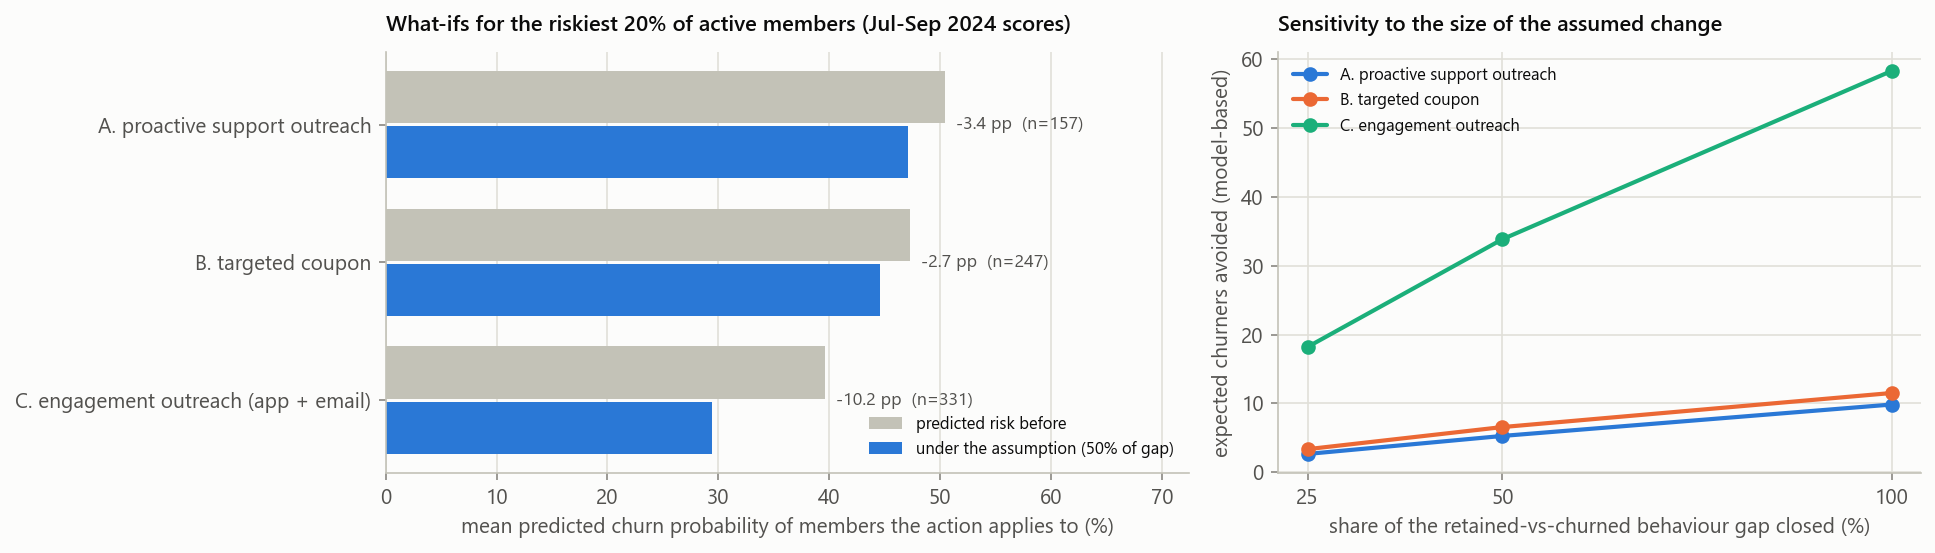

In [4]:
r = tab("retention_scenarios")
display(r[["scenario", "who", "change_per_member", "members_eligible_for_action", "mean_risk_before_eligible",
           "mean_risk_after_eligible", "change_pp_eligible", "expected_churners_avoided_model_based"]].round(3))
fig("retention_scenarios", 1100)

**What does this show?** Left: mean predicted churn risk of the members each action applies to, before and under the assumption. Right: expected churners avoided (model-based) as the assumed share of the behaviour gap changes.

**Why is it relevant?** The brief asks for a retention scenario and the estimated change in churn risk.

**What did we learn?** Engagement outreach moves the model's risk most (-10.2 pp for all 331 targeted members). Coupons and support outreach move it less (-2.7 and -3.4 pp), partly because they apply to fewer members and the gaps are smaller.

**What does it imply?** Test engagement outreach first, with support outreach for members with open tickets as a second arm.

In [5]:
s = tab("retention_scenario_sensitivity")
s.pivot_table(index="scenario", columns="gap_share_closed", values="change_pp_eligible").round(2)

gap_share_closed,0.25,0.50,1.00
scenario,,,
A. proactive support outreach,-1.69,-3.36,-6.26
B. targeted coupon,-1.36,-2.66,-4.66
C. engagement outreach (app + email),-5.50,-10.22,-17.60


## 4. What these numbers do and do not mean
* **Do:** they show how the fitted model's risk responds if a member's recent behaviour looked like a more engaged
  member's, under explicit assumptions. That is enough to rank which actions to test first and on whom.
* **Do not:** they are not causal effects. The model learned that engaged members churn less; it did not learn what
  happens when the business *causes* engagement (a coupon might be redeemed by people who would have stayed anyway).
* **How to measure the real effect:** a randomised test inside the top-risk group with a 20-30% hold-out, comparing
  actual churn after one quarter. No offer costs or member margins were supplied, so no ROI is claimed.